# Hamilton-Jacobi Reachability with Spatially-Varying Disturbance Landscapes
This notebook implements backward reachability analysis for a double integrator system subjected to a state-dependent adversarial disturbance bound field $d \in [-D(x), D(x)]$. 

We evaluate and compare two formulations:
1. **Full Game-Theoretic Formulation:** The controller fights a worst-case spatial adversary.
2. **Net Capability Formulation (Underapproximation):** The disturbance channel is zeroed out, but the control authority is conservatively scaled down point-by-point to $U_{net}(x) = U_{max} - D(x)$.

We benchmark these formulations across 3 distinct environmental disturbance profiles.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import time
from tqdm.notebook import tqdm

from IPython.display import HTML
import matplotlib.animation as anim
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import hj_reachability as hj

from hj_reachability.systems.doubleint import DoubleIntegrator

/home/radams4r/HSL/.venv/lib/python3.12/site-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.10.1 is installed, but it is not compatible with the installed jaxlib version 0.10.2, so it will not be used.
  warnings.warn(


In [42]:
# Disturbance Landscapes

def landscape_1_uniform(state, d_max=1):
    """1. Uniform baseline disturbance everywhere."""
    return d_max

def landscape_2_patterned(state, d_base=0.8, A=0.25, wavelength=4.0):
    """2. Cyclical patterned disturbance using a sinusoidal wave."""
    x1 = state[0]
    return d_base + A * jnp.cos(2 * jnp.pi * x1 / wavelength)

def landscape_3_spike(state, d_base=0.1, A=0.55, center=0.0, sigma=0.35):
    """3. Highly localized wind corridor modeled via a Gaussian spike."""
    x1 = state[0]
    return d_base + A * jnp.exp(-((x1 - center) ** 2) / (2 * sigma ** 2))

def landscape_4_radial_growth(state, d_base=0.1, L=0.25):
    """4. Disturbance magnitude increasing linearly from the origin with Lipschitz constant L."""
    # Euclidean distance from origin: r = ||x||_2 = sqrt(x1^2 + x2^2)
    r = jnp.linalg.norm(state)
    return d_base + L * r

In [43]:
# Implement Custom Dynamics Subclasses strictly adhering to dynamics.py signatures

class DoubleIntDynamics(hj.Dynamics):
    """True game-theoretic system where control minimizes and disturbance maximizes."""
    def __init__(self, u_max, landscape_fn):
        self.u_max = u_max
        self.landscape_fn = landscape_fn
        # Initialize base abstract class with tracking modes
        super().__init__(
            control_mode="min", 
            disturbance_mode="max", 
            control_space=None, 
            disturbance_space=None
        )

    def __call__(self, state, control, disturbance, time):
        x2 = state[1]
        # Extract inputs handling potential array-wrapping from the level-set solver
        u = control[0] if hasattr(control, "__len__") else control
        d = disturbance[0] if hasattr(disturbance, "__len__") else disturbance
        return jnp.array([x2, u + d])

    def optimal_control_and_disturbance(self, state, time, grad_value):
        D_x = self.landscape_fn(state)
        
        # control_mode="min" minimizes the Hamiltonian -> opposite sign of velocity gradient
        u_opt = -jnp.sign(grad_value[1]) * self.u_max
        
        # disturbance_mode="max" maximizes the Hamiltonian -> tracks sign of velocity gradient
        d_opt = jnp.sign(grad_value[1]) * D_x
        
        return jnp.array([u_opt]), jnp.array([d_opt])

    def partial_max_magnitudes(self, state, time, value, grad_value_box):
        D_x = self.landscape_fn(state)
        # Dimension 0 (Position): dx1/dt = x2 -> max speed is |x2|
        # Dimension 1 (Velocity): dx2/dt = u + d -> worst-case combined speed is U_max + D(x)
        return jnp.array([jnp.abs(state[1]), self.u_max + D_x])


class NetCapabilityDynamics(hj.Dynamics):
    """Conservative underapproximation system: zero disturbance, shrunk control authority."""
    def __init__(self, u_max, landscape_fn):
        self.u_max = u_max
        self.landscape_fn = landscape_fn
        super().__init__(
            control_mode="min", 
            disturbance_mode="max", 
            control_space=None, 
            disturbance_space=None
        )

    def __call__(self, state, control, disturbance, time):
        x2 = state[1]
        u = control[0] if hasattr(control, "__len__") else control
        return jnp.array([x2, u])

    def optimal_control_and_disturbance(self, state, time, grad_value):
        D_x = self.landscape_fn(state)
        u_net = jnp.maximum(0.0, self.u_max - D_x)  # Clamp lower bound to physical zero
        
        u_opt = -jnp.sign(grad_value[1]) * u_net
        return jnp.array([u_opt]), jnp.array([0.0])

    def partial_max_magnitudes(self, state, time, value, grad_value_box):
        D_x = self.landscape_fn(state)
        u_net = jnp.maximum(0.0, self.u_max - D_x)
        # u_net = self.u_max - D_x  # Allow negative values to reflect potential backward motion
        return jnp.array([jnp.abs(state[1]), u_net])

In [45]:
# Grid Generation and Target Set Initialization
grid_lower = jnp.array([-15.0, -10.0])
grid_upper = jnp.array([15.0, 10.0])
grid_shape = (201, 201)

# Expand the grid bounds so the solver can trace the full trajectory expansion
grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(
    domain=hj.sets.Box(
        grid_lower,     # Lower bounds: [min_position, min_velocity]
        grid_upper      # Upper bounds: [max_position, max_velocity]
    ),
    shape=grid_shape             # Grid resolution
)

# grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(
#     hj.sets.Box(grid_lower, grid_upper), grid_shape
# )

# Safe target boundary defined as a terminal circle centered at the origin
safety_bound = 5
initial_values = jnp.linalg.norm(grid.states, axis=-1) - safety_bound

print(f"Grid successfully instantiated with shape {grid_shape}.")

import hj_reachability as hj
import numpy as np



Grid successfully instantiated with shape (201, 201).


In [46]:
# Solver Execution Loop across all Landscapes

u_max = 1.0
time_start = 0.0
time_target = -2.0  
times = jnp.linspace(time_start, time_target, 101)

# BRS
# solver_settings = hj.SolverSettings.with_accuracy("high")

# BRT
solver_settings = hj.SolverSettings.with_accuracy(
    "high",
    hamiltonian_postprocessor=hj.solver.backwards_reachable_tube
)

landscapes = [
    {"name": "1. Uniform Field", "fn": landscape_1_uniform},
    {"name": "2. Patterned (Sinusoidal)", "fn": landscape_2_patterned},
    {"name": "3. Radial Growth by Lipschitz Constant", "fn": landscape_4_radial_growth}
]

results = []

for idx, landscape in enumerate(landscapes):
    print(f"Solving HJ PDE equations for Landscape: {landscape['name']}...")
    
    # Initialize game dynamics (control MINIMIZES, disturbance MAXIMIZES)
    game_dyn = DoubleIntDynamics(u_max=u_max, landscape_fn=landscape["fn"])
    
    # Initialize net capability underapproximation dynamics
    net_dyn = NetCapabilityDynamics(u_max=u_max, landscape_fn=landscape["fn"])
    
    # Propagate value functions backward through time using hj.solve
    game_values = hj.solve(solver_settings, game_dyn, grid, times, initial_values)
    net_values = hj.solve(solver_settings, net_dyn, grid, times, initial_values)
    
    # Vectorize landscape calculations across the state grid for plotting
    landscape_map = jax.vmap(jax.vmap(landscape["fn"]))(grid.states)
    
    # Store final values (at time t = -2.0)
    results.append({
        "name": landscape["name"],
        "game_v": game_values[-1],
        "net_v": net_values[-1],
        "map": landscape_map
    })

print("All reachability computations completed successfully.")

Solving HJ PDE equations for Landscape: 1. Uniform Field...


100%|##########|  2.0000/2.0 [00:00<00:00,  4.33sim_s/s]
100%|##########|  2.0000/2.0 [00:00<00:00,  6.56sim_s/s]


Solving HJ PDE equations for Landscape: 2. Patterned (Sinusoidal)...


100%|##########|  2.0000/2.0 [00:00<00:00,  6.04sim_s/s]
100%|##########|  2.0000/2.0 [00:00<00:00,  6.61sim_s/s]


Solving HJ PDE equations for Landscape: 3. Radial Growth by Lipschitz Constant...


100%|##########|  2.0000/2.0 [00:00<00:00,  3.82sim_s/s]
100%|##########|  2.0000/2.0 [00:00<00:00,  7.19sim_s/s]

All reachability computations completed successfully.


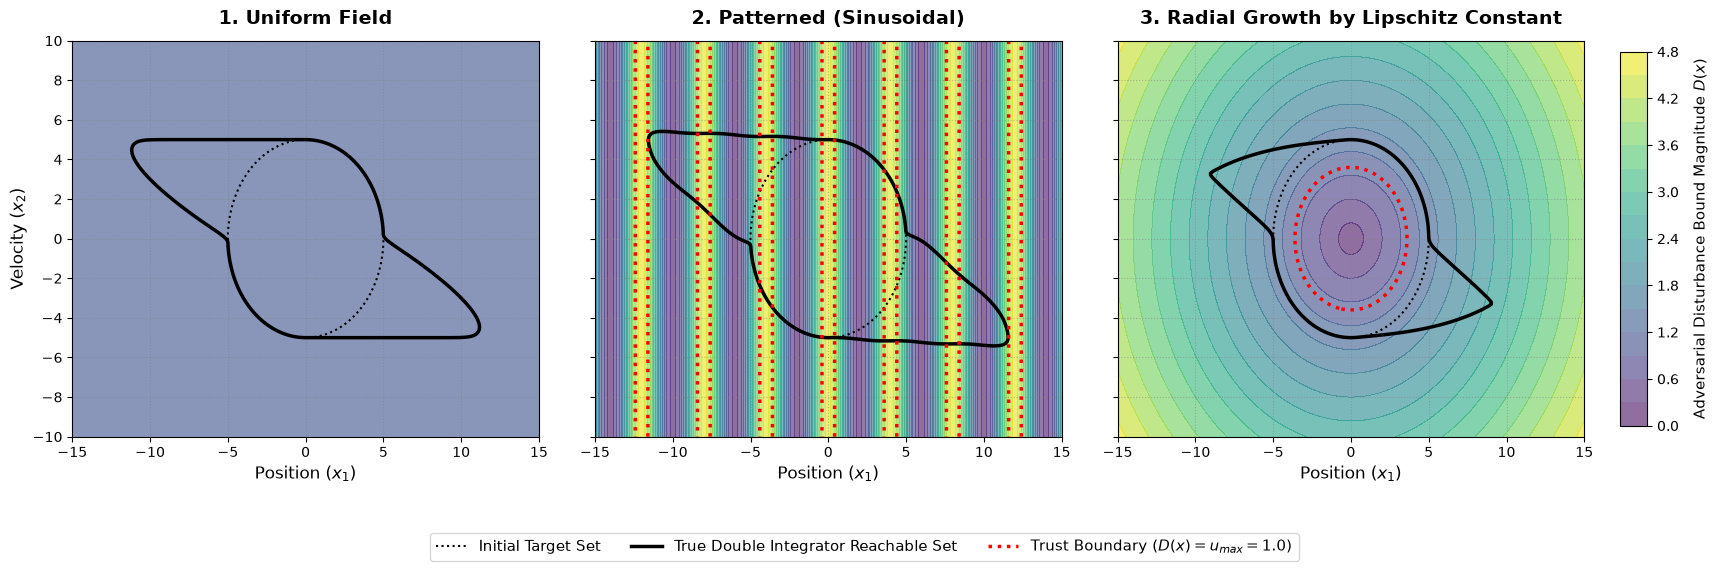

In [47]:
# # Generate Comparative Plots

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

x1_coords = grid.coordinate_vectors[0]
x2_coords = grid.coordinate_vectors[1]

# Define plot display bounds based on the enlarged grid
X1_LIMITS = (grid_lower[0], grid_upper[0])  # Position range
X2_LIMITS = (grid_lower[1], grid_upper[1])    # Velocity range

for i, res in enumerate(results):
    ax = axes[i]
    
    # 1. Plot Disturbance Landscape Background
    contour_bg = ax.contourf(
        x1_coords, x2_coords, res["map"].T, 
        levels=15, cmap='viridis', alpha=0.6
    )
    
    # 2. Target Boundary (Dotted Line)
    ax.contour(
        x1_coords, x2_coords, initial_values.T, levels=[0.0], 
        colors="black", linestyles="dotted", linewidths=1.5
    )
    
    # 3. True Game Reachable Set Boundary (Solid Line)
    ax.contour(
        x1_coords, x2_coords, res["game_v"].T, levels=[0.0], 
        colors="black", linestyles="solid", linewidths=2.5
    )
    
    # 4. Net Capability Boundary Underapproximation (Dashed Line)
    # net_v_trusted = np.where(res["map"].T <= u_max, res["net_v"].T, np.nan)
    
    # ax.contour(
    #     x1_coords, x2_coords, net_v_trusted, levels=[0.0], 
    #     colors="black", linestyles="dashed", linewidths=2.0
    # )
    
    # 5. Trust Region Boundary where D(x) = u_max (Red Dotted Line)
    ax.contour(
        x1_coords, x2_coords, res["map"].T, levels=[u_max],
        colors="red", linestyles="dotted", linewidths=2.5
    )
    
    ax.set_xlim(X1_LIMITS)
    ax.set_ylim(X2_LIMITS)
    
    # Grid ticks
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5.0))  # Ticks every 5 units for Position
    ax.yaxis.set_major_locator(ticker.MultipleLocator(2.0))  # Ticks every 2 units for Velocity
    
    ax.set_title(res["name"], fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("Position ($x_1$)", fontsize=12)
    if i == 0:
        ax.set_ylabel("Velocity ($x_2$)", fontsize=12)
        
    ax.grid(True, linestyle=":", alpha=0.5, color="gray")

# Custom Legend below plots
legend_lines = [
    plt.Line2D([0], [0], color="black", linestyle=":", linewidth=1.5),
    plt.Line2D([0], [0], color="black", linestyle="solid", linewidth=2.5),
    # plt.Line2D([0], [0], color="black", linestyle="dashed", linewidth=2.0),
    plt.Line2D([0], [0], color="red", linestyle=":", linewidth=2.5)
]

fig.legend(
    legend_lines, 
    [
        "Initial Target Set", 
        "True Double Integrator Reachable Set", 
        # "Trusted Net Capability (within $D(x) <= u_{max}$)",
        f"Trust Boundary ($D(x) = u_{{max}} = {u_max}$)"
    ], 
    loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=4, fontsize=11, frameon=True
)

# Colorbar placement
cbar_ax = fig.add_axes([0.92, 0.18, 0.015, 0.68])
cbar = fig.colorbar(contour_bg, cax=cbar_ax)
cbar.set_label("Adversarial Disturbance Bound Magnitude $D(x)$", fontsize=11, labelpad=10)

plt.subplots_adjust(left=0.06, right=0.90, bottom=0.16, top=0.88, wspace=0.12)
plt.show()